# OSM roads with real noise values (dB) — Milan

Regression counterpart of `MIL_OSM_roads_noise_class.ipynb`, mirroring Barcelona's `OSM_roads_noise_regre.ipynb`.

The raw dB values were already computed by the class pipeline (same segments, same noise assignment) and stored in `../layers/MIL_noise_streets.gpkg`; here they simply replace the 0–4 noise classes, so all road features stay **identical** to the classification dataset.

Milan law defines only diurnal (06-22) and nocturnal (22-06) periods — the evening dB is set equal to day, as in the class pipeline. The dB values are acoustic-zoning legal limits, not modeled noise.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt

## Load the class-pipeline road features and the noise streets layer

In [2]:
roads_class = pd.read_csv("data/osm_roads_noise_class.csv")
noise_streets = gpd.read_file("../layers/MIL_noise_streets.gpkg")

print("Class CSV:", roads_class.shape)
print("Noise streets:", noise_streets.shape)
roads_class.head()

Class CSV: (22164, 11)
Noise streets: (22164, 12)


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,10371529_743371634_0,3,3,2,2,1139.168597,0.000000,3243.971228,0.000000,295.923522,288.328932
1,10371529_743371622_0,3,3,2,4,1106.773564,0.000000,3243.971228,0.000000,289.266957,266.547014
2,10371530_267873043_0,3,3,2,2,2119.581742,0.000000,1317.601503,79.177942,14.866980,1472.511721
3,13595397_271096577_0,3,3,2,3,0.000000,436.049701,0.000000,194.533835,13.506098,2720.309808
4,13595397_344814479_0,3,3,2,3,10.182633,436.049701,0.000000,194.533835,0.000000,2717.720476


## Replace the noise classes with the raw dB values

In [3]:
db = noise_streets[['segment_id']].copy()
db['noise_day'] = noise_streets['db_diurno'].astype(float)
db['noise_evening'] = noise_streets['db_diurno'].astype(float)
db['noise_night'] = noise_streets['db_notturno'].astype(float)
db['segment_id'] = db['segment_id'].astype(str)

roads_regre = roads_class.drop(columns=['noise_day', 'noise_evening', 'noise_night']).copy()
roads_regre['road_id'] = roads_regre['road_id'].astype(str)
roads_regre = roads_regre.merge(db, left_on='road_id', right_on='segment_id', how='left')
roads_regre = roads_regre.drop(columns=['segment_id'])

# restore the Barcelona column order: noise columns right after road_id
noise_cols = ['noise_day', 'noise_evening', 'noise_night']
ordered = ['road_id'] + noise_cols + [c for c in roads_regre.columns if c != 'road_id' and c not in noise_cols]
roads_regre = roads_regre[ordered]

print(f"Rows: {len(roads_regre)} (class CSV: {len(roads_class)})")
roads_regre[noise_cols].describe()

Rows: 22164 (class CSV: 22164)


,noise_day,noise_evening,noise_night
count,22164.000000,22164.000000,22164.000000
mean,63.115412,63.115412,53.115412
std,2.972530,2.972530,2.972530
min,55.000000,55.000000,45.000000
25%,60.000000,60.000000,50.000000
50%,65.000000,65.000000,55.000000
75%,65.000000,65.000000,55.000000
max,70.000000,70.000000,60.000000


## Sanity checks

In [4]:
assert len(roads_regre) == len(roads_class), "row count changed by the merge"
assert roads_regre[noise_cols].isna().sum().sum() == 0, "NaN noise values after merge"
print("dB ranges:")
print(roads_regre[noise_cols].agg(['min', 'max']))
print("All sanity checks passed.")

dB ranges:
     noise_day  noise_evening  noise_night
min       55.0           55.0         45.0
max       70.0           70.0         60.0
All sanity checks passed.


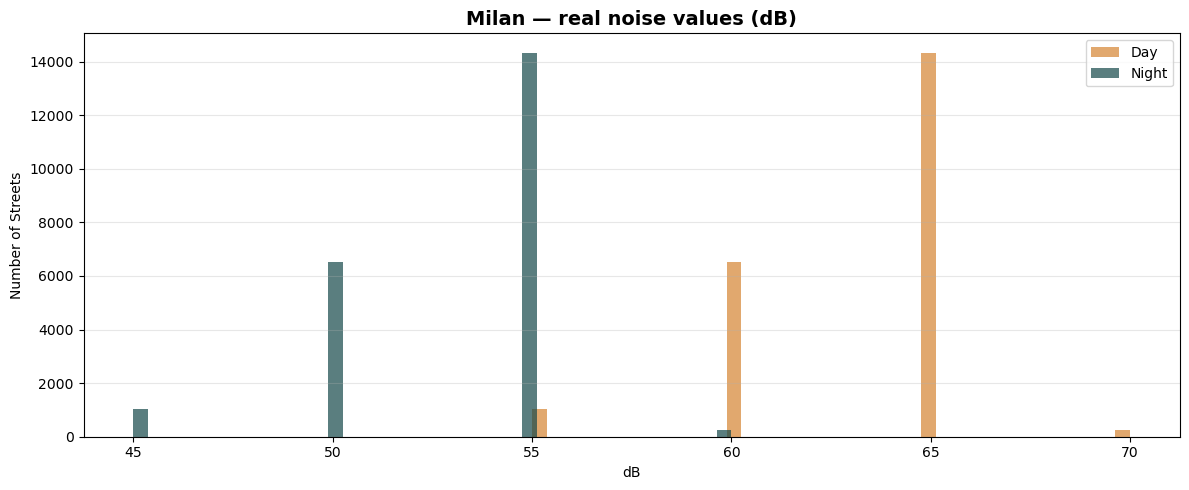

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(roads_regre['noise_day'], bins=40, color='#d58430', alpha=0.7, label='Day')
ax.hist(roads_regre['noise_night'], bins=40, color='#144849', alpha=0.7, label='Night')
ax.set_title('Milan — real noise values (dB)', fontsize=14, fontweight='bold')
ax.set_xlabel('dB')
ax.set_ylabel('Number of Streets')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Export to CSV

In [6]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
roads_regre.to_csv(os.path.join(output_dir, "osm_roads_noise_regre.csv"), index=False)
print("Exported osm_roads_noise_regre.csv")

Exported osm_roads_noise_regre.csv
